In [33]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [45]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[8].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.204,2041.404],
    [2047.4961,2047.6481],
    [2051.4334,2051.6652],
    [2053.416,2053.715],
    [2058.108,2058.276],
    [2037.663,2037.787],
    [2058.8291,2058.8768],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.82051, 2039.84413],
    [2039,1769,2039.2141],
    [2039.3400,2039.3707],
    [2039.3000,2039.3707],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2051.438,2051.772],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.5068, 2047.6352],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2058.8328,2058.8928],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.8243, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.8317,2058.8757],
    [2059.10883, 2059.11091],
    [2058.803,2058.912],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109]
]


vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)

#flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=True, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)
#x_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
#y_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd[1].flux_err, dtype=np.float64)

flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=True, break_tolerance=100, niters=4, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)

<IPython.core.display.Javascript object>


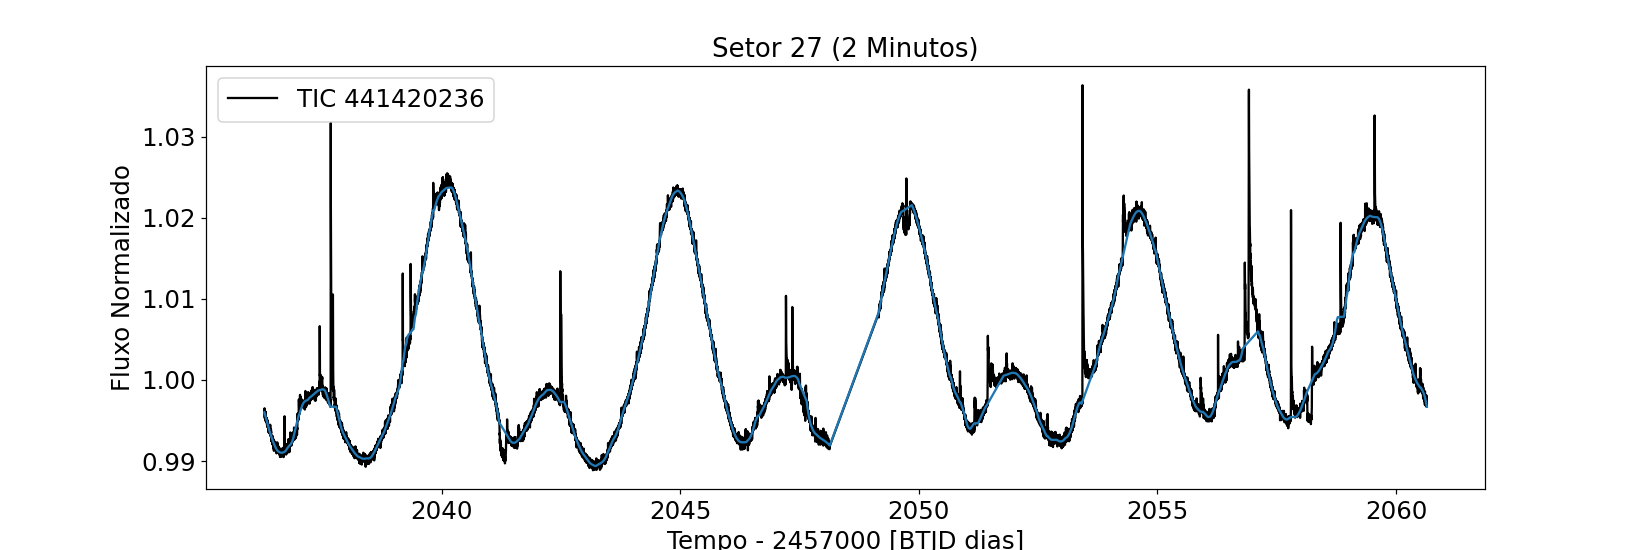

In [49]:

plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
plt.plot(x_detrend,y_detrend)
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 27 (2 Minutos)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()
plt.savefig('setor27_ajuste.png', format='png')

In [36]:
flcd.to_fits(path='lightcurve_02.fits', overwrite=True)
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve_02.fits')
type(hdu)

from astropy.table import Table
dat = Table.read('lightcurve_02.fits', format='fits')
df = dat.to_pandas()
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
#print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [37]:
#%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

<IPython.core.display.Javascript object>


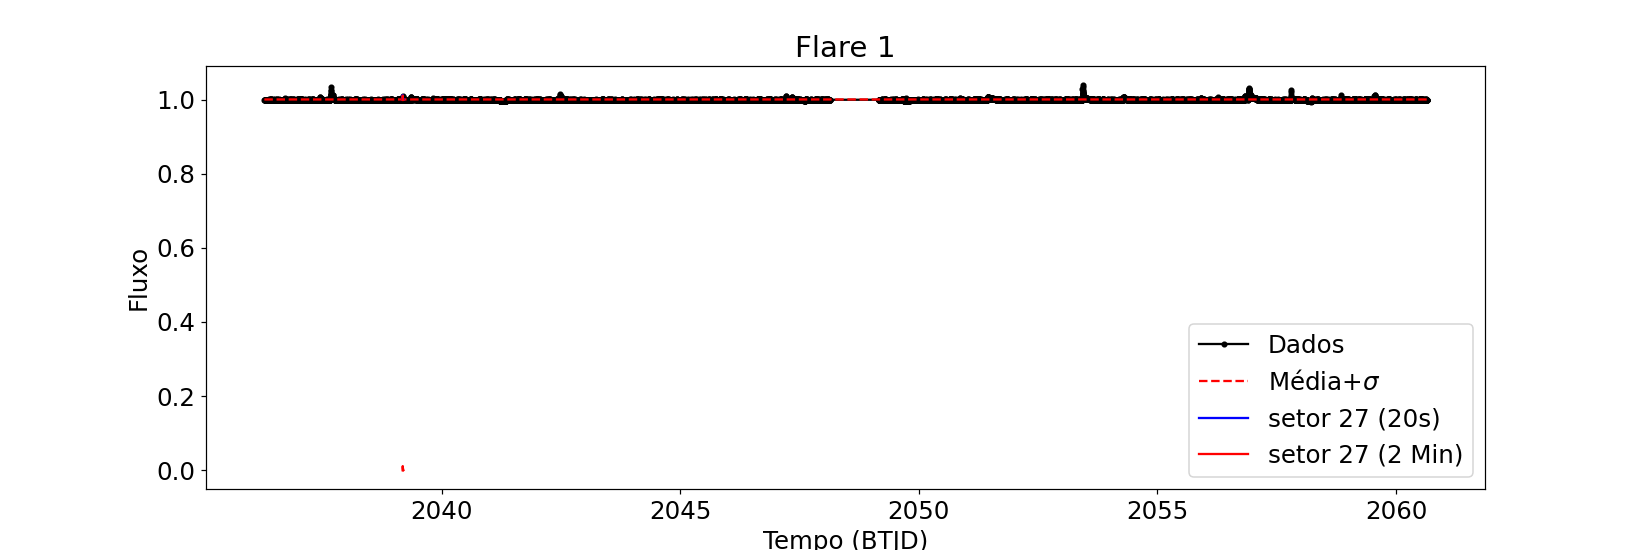

In [38]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.mean(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+(1/3*np.array(np.std(flux))), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

In [39]:
# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 2039.18133
stop_input = 2039.1992

def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
print(flux_flare)
print(tempo_flare)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

[0.99966043 1.0067737  1.0108382  1.0070429  1.0050498  1.0026008
 1.0026575  1.002145   1.0023038  1.0018557  1.0016097  1.0003897
 0.9999128 ]
[2039.18133781 2039.18272673 2039.18411566 2039.18550459 2039.18689352
 2039.18828244 2039.18967137 2039.1910603  2039.19244923 2039.19383815
 2039.19522708 2039.19661601 2039.19800494]


In [40]:
##### Alguns dados básicos##################
fl129=pd.read_csv('flares_setor1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
tf = pd.DataFrame(tess_f)
df = pd.DataFrame(fl129)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [41]:

#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 

#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4

###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
##### Alguns dados básicos##################



In [42]:
flux_flare1 = np.array(flux_flare)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

7.970489610928035e+32


In [43]:
# Arrays fornecidos
array1 = [0.99966043, 1.0067737, 1.0108382, 1.0070429, 1.0050498, 1.0026008, 1.0026575, 1.002145, 1.0023038, 1.0018557, 1.0016097, 1.0003897, 0.9999128]
array2 = [2039.18133781, 2039.18272673, 2039.18411566, 2039.18550459, 2039.18689352, 2039.18828244, 2039.18967137, 2039.1910603, 2039.19244923, 2039.19383815, 2039.19522708, 2039.19661601, 2039.19800494]

fluxo_flare1 = [0.9999635, 1.0012709, 1.0026513, 1.0068452, 1.0083339, 1.0091891, 1.0106537,
1.0125064, 1.0107701, 1.0097594, 1.0094416, 1.0088161, 1.0088227, 1.0080512,
1.0069151, 1.0065935, 1.0040841, 1.0053813, 1.0055312, 1.0036963, 1.0053453,
1.0052593, 1.002721, 1.0036173, 1.0036532, 1.0025586, 1.0029771, 1.0014732,
1.0016732, 1.0039657, 1.0014905, 1.0019453, 1.0017294, 1.002086, 1.002761,
1.0023755, 1.0012082, 1.0023572, 1.0026678, 1.0024121, 1.0024387, 1.0024604,
1.0029957, 1.0019627, 1.00199, 1.002631, 1.002016, 1.0019307, 1.0011969,
1.0015295, 1.0014598, 1.0014782, 1.0017085, 1.0021398, 1.0009825, 1.0012045,
1.0006484, 1.0023483, 1.0009371, 1.0000916]

tempo_flare2 = [2039.18168504, 2039.18214801, 2039.1823795, 2039.18261099, 2039.18284248,
2039.18307397, 2039.18330545, 2039.18376843, 2039.18399992, 2039.18446289,
2039.18469438, 2039.18492587, 2039.18515736, 2039.18538884, 2039.18562033,
2039.18585182, 2039.18608331, 2039.1863148, 2039.18654628, 2039.18677777,
2039.18700926, 2039.18724075, 2039.18747224, 2039.18770372, 2039.18793521,
2039.1881667, 2039.18839819, 2039.18862968, 2039.18886116, 2039.18909265,
2039.18932414, 2039.18955563, 2039.18978711, 2039.1900186, 2039.19025009,
2039.19048158, 2039.19071307, 2039.19094455, 2039.19140753, 2039.19163902,
2039.19187051, 2039.19210199, 2039.19233348, 2039.19256497, 2039.19279646,
2039.19302795, 2039.19325943, 2039.19349092, 2039.19372241, 2039.1939539,
2039.19418538, 2039.19441687, 2039.19464836, 2039.19487985, 2039.19511134,
2039.19534282, 2039.19557431, 2039.1958058, 2039.19603729, 2039.19626878]


amplitude_flare = max(fluxo_flare1) - min(fluxo_flare1)
amplitude_flare2 = max(array1) - min(array1)
print(amplitude_flare2)



# Plotar os gráficos
plt.plot(tempo_flare2,fluxo_flare1, 'b', label='setor 27 (20s)')
plt.plot(array2, array1, 'r', label='setor 27 (2 Min)')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Flare 1')


# Adicionar a legenda
plt.legend()

# Mostrar o gráfico
plt.show()



0.011177769999999976
